In [2]:
import matplotlib.pyplot as plt

from src.model import _DiffusionBase

/home/justin/msc_ai/individual-project/diffusion-irregular-ehr/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Beta-clipping Investigation

In [ ]:
import torch
import yaml

from src.config import Config
from src.data import load_ihdp
from src.model import DiffPO, HybridModel

In [4]:
with open("config/ihdp.yaml") as f:
    cfg = Config.model_validate(yaml.safe_load(f))

train_ds, val_ds, _, y_std = load_ihdp(
    cfg.data.path,
    replication=cfg.data.replication,
    train_ratio=cfg.data.train_ratio,
    test_ratio=cfg.data.test_ratio,
)
print("y_std:", y_std)

a, y_fac, y_cf = train_ds.a, train_ds.y, train_ds.y_cf
y_both = torch.stack(
    [y_fac * (1 - a) + y_cf * a, y_fac * a + y_cf * (1 - a)], dim=1
)  # exact formula from _noise_targets

print("max abs:", y_both.abs().max().item())
print("mean/std:", y_both.mean().item(), y_both.std().item())
print("99.9th percentile:", y_both.abs().quantile(0.999).item())

CLIP_VAL = y_both.abs().max().item() * 2
print("CLIP_VAL:", CLIP_VAL)

y_std: 2.439351797103882
max abs: 3.009382486343384
mean/std: 0.19222968816757202 1.0039902925491333
99.9th percentile: 2.5268349647521973
CLIP_VAL: 6.018764972686768


In [5]:
model = DiffPO(cfg.model, cfg.diffusion)
sd_naive_full = torch.load(
    "checkpoints/final_model_naive_full_2026-08-03T16_21_12.pth", map_location="cpu"
)
model.load_state_dict(sd_naive_full)
model.eval()

K = 50
x = val_ds.x
a = val_ds.a
confounder = torch.tensor(val_ds.confounder, dtype=torch.long)
x_rep = x.repeat_interleave(K, dim=0)
a_rep = a.repeat_interleave(K, dim=0)
confounder_rep = confounder.repeat_interleave(K, dim=0)

groups = {
    "all": torch.ones_like(a_rep, dtype=torch.bool),
    "conf=0,a=0": (confounder_rep == 0) & (a_rep == 0),
    "conf=0,a=1": (confounder_rep == 0) & (a_rep == 1),
    "conf=1,a=0": (confounder_rep == 1) & (a_rep == 0),
    "conf=1,a=1": (confounder_rep == 1) & (a_rep == 1),
}
for name, mask in groups.items():
    print(f"{name}: {mask.sum().item()} samples, {mask.float().mean().item():.2%} of total")

all: 7400 samples, 100.00% of total
conf=0,a=0: 2400 samples, 32.43% of total
conf=0,a=1: 1550 samples, 20.95% of total
conf=1,a=0: 2200 samples, 29.73% of total
conf=1,a=1: 1250 samples, 16.89% of total


In [35]:
BK = len(val_ds) * K

steps = range(model.L - 1, -1, -1)


def ddpm_reverse(
    model: _DiffusionBase,
    cond: torch.Tensor,
    a_rep: torch.Tensor,
    confounder_rep: torch.Tensor,
    clip_val: float | None = None,
    return_split_pos: bool = False,
):
    torch.manual_seed(0)
    y = torch.randn(BK, 2)

    groups = {
        "all": torch.ones_like(a_rep, dtype=torch.bool),
        "conf=0,a=0": (confounder_rep == 0) & (a_rep == 0),
        "conf=0,a=1": (confounder_rep == 0) & (a_rep == 1),
        "conf=1,a=0": (confounder_rep == 1) & (a_rep == 0),
        "conf=1,a=1": (confounder_rep == 1) & (a_rep == 1),
    }

    eps_pred_lists = {name: [] for name in groups}
    y_abs_mean_lists = {name: [] for name in groups}
    y_abs_max_lists = {name: [] for name in groups}

    eps_pred_y0_lists = {name: [] for name in groups}
    y0_abs_mean_lists = {name: [] for name in groups}
    y0_abs_max_lists = {name: [] for name in groups}

    eps_pred_y1_lists = {name: [] for name in groups}
    y1_abs_mean_lists = {name: [] for name in groups}
    y1_abs_max_lists = {name: [] for name in groups}

    with torch.no_grad():
        for step in steps:
            tau = torch.full((BK,), step, dtype=torch.long)

            eps_pred = model.denoiser(y, tau, cond, a_rep)
            alpha_bar = model.alpha_bar_sched[step]
            beta = model.beta_sched[step]
            alpha = model.alpha_sched[step]

            if clip_val is not None:
                alpha_bar_safe = alpha_bar.clamp(min=1e-15)
                clean_pred = (y - (1.0 - alpha_bar_safe).sqrt() * eps_pred) / alpha_bar.sqrt()
                clean_pred = clean_pred.clamp(-clip_val, clip_val)

            mu = (1.0 / alpha.sqrt()) * (y - (beta / (1.0 - alpha_bar).sqrt()) * eps_pred)

            if step > 0:
                alpha_bar_prev = model.alpha_bar_sched[step - 1]

                if clip_val is not None:
                    mu = (alpha_bar_prev.sqrt() * beta / (1.0 - alpha_bar)) * clean_pred + (
                        (1.0 - alpha_bar_prev) * alpha.sqrt() / (1.0 - alpha_bar)
                    ) * y

                sigma = ((1.0 - alpha_bar_prev) / (1.0 - alpha_bar) * beta).sqrt()
                y = mu + sigma * torch.randn_like(mu)
            else:
                y = mu if clip_val is None else clean_pred

            for name, mask in groups.items():
                if mask.any():
                    eps_pred_lists[name].append(eps_pred[mask].abs().mean().item())
                    y_abs_mean_lists[name].append(y[mask].abs().mean().item())
                    y_abs_max_lists[name].append(y[mask].abs().max().item())

                    eps_pred_y0_lists[name].append(eps_pred[mask, 0].abs().mean().item())
                    y0_abs_mean_lists[name].append(y[mask, 0].abs().mean().item())
                    y0_abs_max_lists[name].append(y[mask, 0].abs().max().item())

                    eps_pred_y1_lists[name].append(eps_pred[mask, 1].abs().mean().item())
                    y1_abs_mean_lists[name].append(y[mask, 1].abs().mean().item())
                    y1_abs_max_lists[name].append(y[mask, 1].abs().max().item())

                else:
                    eps_pred_lists[name].append(float("nan"))
                    y_abs_mean_lists[name].append(float("nan"))
                    y_abs_max_lists[name].append(float("nan"))

                    eps_pred_y0_lists[name].append(float("nan"))
                    y0_abs_mean_lists[name].append(float("nan"))
                    y0_abs_max_lists[name].append(float("nan"))

                    eps_pred_y1_lists[name].append(float("nan"))
                    y1_abs_mean_lists[name].append(float("nan"))
                    y1_abs_max_lists[name].append(float("nan"))

    # Return in reversed order to match the original time steps tau=0...L-1
    for name in groups:
        eps_pred_lists[name].reverse()
        y_abs_mean_lists[name].reverse()
        y_abs_max_lists[name].reverse()

        eps_pred_y0_lists[name].reverse()
        y0_abs_mean_lists[name].reverse()
        y0_abs_max_lists[name].reverse()

        eps_pred_y1_lists[name].reverse()
        y1_abs_mean_lists[name].reverse()
        y1_abs_max_lists[name].reverse()

    if not return_split_pos:
        return eps_pred_lists, y_abs_mean_lists, y_abs_max_lists

    return (
        eps_pred_y0_lists,
        y0_abs_mean_lists,
        y0_abs_max_lists,
        eps_pred_y1_lists,
        y1_abs_mean_lists,
        y1_abs_max_lists,
    )

In [16]:
def plot_y(ax, y_mean_list, y_max_list, semilogy=False):
    ax.plot(y_mean_list, label="y.abs.mean")
    ax.plot(y_max_list, label="y.abs.max")
    ax.set_xlim(ax.get_xlim()[::-1])
    ax.set_xlabel(r"Diffusion step $\tau$")

    title = "Predicted Outcomes"

    if semilogy:
        ax.semilogy()
        title += " (log scale)"

    ax.set_title(title)
    ax.legend()
    ax.grid()

### No clipping

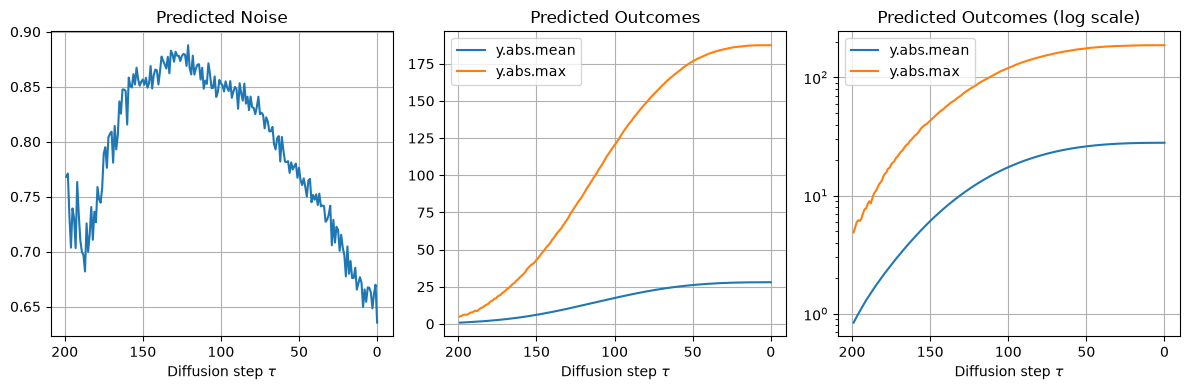

In [17]:
eps_pred_lists, y_mean_lists, y_max_lists = ddpm_reverse(model, x_rep, a_rep, confounder_rep)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 4))

ax0.plot(eps_pred_lists["all"], label="eps_pred.abs.mean")
ax0.set_xlim(ax0.get_xlim()[::-1])
ax0.set_xlabel(r"Diffusion step $\tau$")
ax0.set_title("Predicted Noise")
ax0.grid()

plot_y(ax1, y_mean_lists["all"], y_max_lists["all"])
plot_y(ax2, y_mean_lists["all"], y_max_lists["all"], semilogy=True)

plt.tight_layout()
plt.show()

### Clip clean prediction

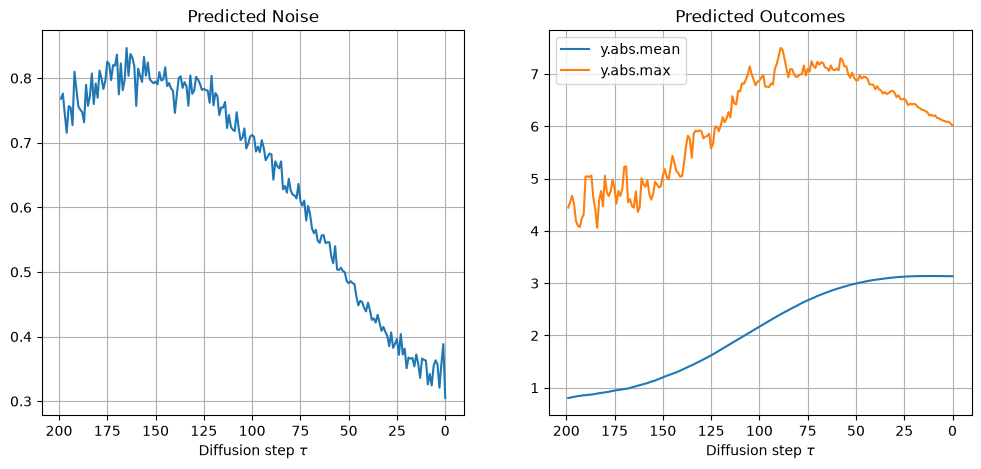

In [18]:
eps_pred_lists, y_mean_lists, y_max_lists = ddpm_reverse(
    model, x_rep, a_rep, confounder_rep, clip_val=CLIP_VAL
)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))

ax0.plot(eps_pred_lists["all"], label="eps_pred.abs.mean")
ax0.set_xlim(ax0.get_xlim()[::-1])
ax0.set_xlabel(r"Diffusion step $\tau$")
ax0.set_title("Predicted Noise")
ax0.grid()

plot_y(ax1, y_mean_lists["all"], y_max_lists["all"])
plt.show()

### Clip clean prediction - `hybrid_conf`

In [ ]:
from src.data import make_ihdp_confounded

hybrid_model = HybridModel(cfg.model, cfg.diffusion)

train_ds_conf, val_ds_conf = (
    make_ihdp_confounded(ds, effect=cfg.data.confounder_effect) for ds in (train_ds, val_ds)
)

sd_hybrid_conf = torch.load(
    "checkpoints/final_model_hybrid_conf_2026-08-21T12_46_12_rep1.pth", map_location="cpu"
)
hybrid_model.load_state_dict(sd_hybrid_conf)
hybrid_model.eval()

x = val_ds_conf.x
a = val_ds_conf.a
x_rep = x.repeat_interleave(K, dim=0)
a_rep = a.repeat_interleave(K, dim=0)

y_hat = hybrid_model.aux_outcome.sample(x_rep, a_rep)
z, _, _ = hybrid_model.encoder.rsample(x_rep, a_rep, y_hat)

a, y_fac, y_cf = train_ds_conf.a, train_ds_conf.y, train_ds_conf.y_cf
y_both_conf = torch.stack(
    [y_fac * (1 - a) + y_cf * a, y_fac * a + y_cf * (1 - a)], dim=1
)  # exact formula from _noise_targets

CLIP_VAL_CONF = y_both_conf.abs().max().item() * 2
print("CLIP_VAL_CONF:", CLIP_VAL_CONF)

groups = {
    "all": torch.ones_like(a_rep, dtype=torch.bool),
    "conf=0,a=0": (confounder_rep == 0) & (a_rep == 0),
    "conf=0,a=1": (confounder_rep == 0) & (a_rep == 1),
    "conf=1,a=0": (confounder_rep == 1) & (a_rep == 0),
    "conf=1,a=1": (confounder_rep == 1) & (a_rep == 1),
}
for name, mask in groups.items():
    print(f"{name}: {mask.sum().item()} samples, {mask.float().mean().item():.2%} of total")

CLIP_VAL_CONF: 7.191953659057617
all: 7400 samples, 100.00% of total
conf=0,a=0: 2400 samples, 32.43% of total
conf=0,a=1: 1550 samples, 20.95% of total
conf=1,a=0: 1250 samples, 16.89% of total
conf=1,a=1: 2200 samples, 29.73% of total


In [37]:
eps_pred_lists, y_mean_lists, y_max_lists = ddpm_reverse(
    hybrid_model, z, a_rep, confounder_rep, clip_val=CLIP_VAL_CONF
)

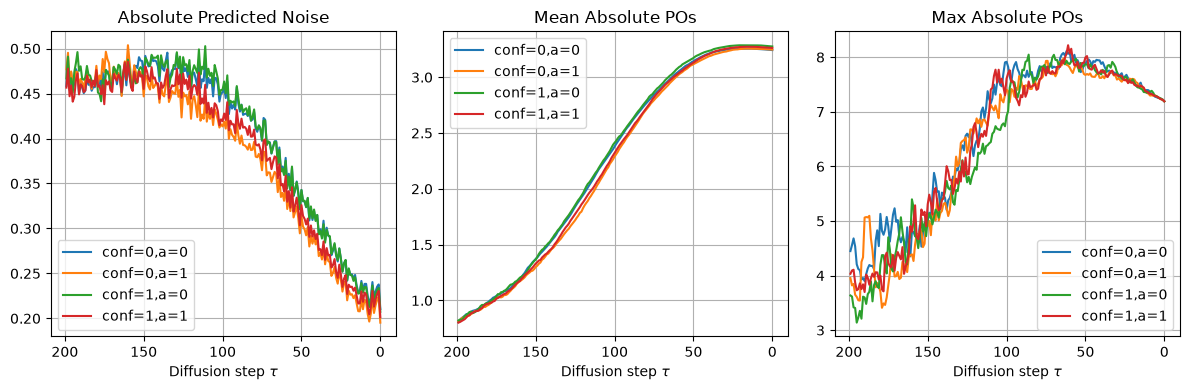

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

metric_lists = [eps_pred_lists, y_mean_lists, y_max_lists]
plot_titles = ["Absolute Predicted Noise", "Mean Absolute POs", "Max Absolute POs"]

for ax, metric, title in zip(axs, metric_lists, plot_titles, strict=True):
    for key, val in metric.items():
        if key != "all":
            ax.plot(val, label=key)
    ax.set_xlim(ax.get_xlim()[::-1])
    ax.set_xlabel(r"Diffusion step $\tau$")
    ax.set_title(title)
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

## `y0` vs `y1` comparison

In [39]:
output = ddpm_reverse(
    hybrid_model, z, a_rep, confounder_rep, clip_val=CLIP_VAL_CONF, return_split_pos=True
)
output[0].keys()

dict_keys(['all', 'conf=0,a=0', 'conf=0,a=1', 'conf=1,a=0', 'conf=1,a=1'])

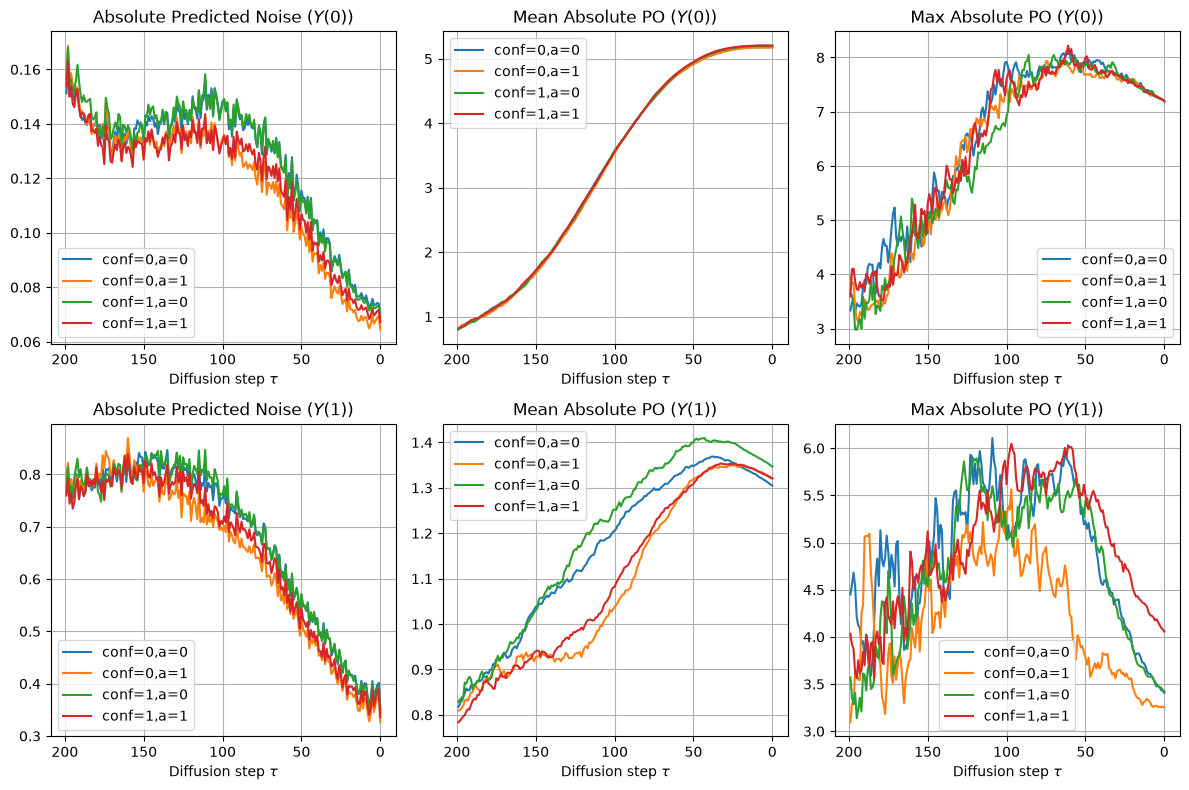

In [40]:
fig, (row0, row1) = plt.subplots(2, 3, figsize=(12, 8))

y0_lists = output[:3]
y1_lists = output[3:]

plot_titles = ["Absolute Predicted Noise", "Mean Absolute PO", "Max Absolute PO"]

for ax, metric, title in zip(row0, y0_lists, plot_titles, strict=True):
    for key, val in metric.items():
        if key != "all":
            ax.plot(val, label=key)
    ax.set_xlim(ax.get_xlim()[::-1])
    ax.set_xlabel(r"Diffusion step $\tau$")
    ax.set_title(title + r" ($Y(0)$)")
    ax.legend()
    ax.grid()

for ax, metric, title in zip(row1, y1_lists, plot_titles, strict=True):
    for key, val in metric.items():
        if key != "all":
            ax.plot(val, label=key)
    ax.set_xlim(ax.get_xlim()[::-1])
    ax.set_xlabel(r"Diffusion step $\tau$")
    ax.set_title(title + r" ($Y(1)$)")
    ax.legend()
    ax.grid()


plt.tight_layout()
plt.show()